In [23]:
import pandas as pd
from itertools import product
import numpy as np
from pathlib import Path

In [2]:
apple = pd.read_parquet('Apple.parquet')
btc = pd.read_parquet('BTC.parquet')
qqq = pd.read_parquet('QQQ.parquet')
spx = pd.read_parquet('spx.parquet')
tesla = pd.read_parquet('Tesla.parquet')
dfs = {
    "apple": apple,
    "btc": btc,
    "qqq": qqq,
    "spx": spx,
    "tesla": tesla,}

In [8]:
h = [3, 5, 10, 30, 60]

In [6]:
em_map = {
    "target_3": 2,
    "target_5": 4,
    "target_10": 9,
    "target_30": 29,
    "target_60": 59,
}

In [9]:
apple.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2014-09-17,22.380634,22.429106,22.162511,22.312332,243706000
2014-09-18,22.426899,22.550281,22.376223,22.457744,149197600
2014-09-19,22.244028,22.550280,22.142679,22.537061,283609600
2014-09-22,22.266066,22.504017,22.160310,22.429107,211153600
2014-09-23,22.614176,22.680274,22.151493,22.164712,253608800


In [28]:
def walk_forward(Y_true, Y_pred, dates, tr, te, em, h):
    preds = []
    n = len(Y_true)
    t = np.arange(n)
    for k in range(0, n - tr - 2*em - te + 1, te):

        train = t[k : k + tr]
        test = t[k + tr + 2*em : k + tr + 2*em + te]

        pos = model(
            Y_train = Y_true[train],
            Y_hat_train = Y_pred[train],
            Y_hat_test = Y_pred[test],
            h = h
        )
        fold = pd.DataFrame({
            "position": pos
        }, index=dates[test])

        preds.append(fold)

    return pd.concat(preds)

In [53]:
def model(Y_train, Y_hat_train, Y_hat_test, h):

    m = np.isfinite(Y_train) & np.isfinite(Y_hat_train)
    Y_train = Y_train[m]
    Y_hat_train = Y_hat_train[m]

    taus = np.quantile(Y_hat_train, np.arange(.05, .96, .05))

    best_pnl = -np.inf
    best_tau_long = taus[-1]
    best_tau_short = taus[0]

    for tau_long in taus:
        for tau_short in taus:

            if tau_short >= tau_long:
                continue

            pos = np.where(Y_hat_train > tau_long, 1,
                  np.where(Y_hat_train < tau_short, -1, 0))

            if (pos != 0).sum() < 10:
                continue

            pnl_ = (pos * Y_train).sum()

            if pnl_ > best_pnl:
                best_pnl = pnl_
                best_tau_long = tau_long
                best_tau_short = tau_short

    return np.where(Y_hat_test > best_tau_long, 1,
           np.where(Y_hat_test < best_tau_short, -1, 0))

In [52]:
def pnl(pos, close, h):
    close = close.squeeze()
    ret = np.log(close).diff()

    sig = pd.Series(pos, index=pos.index)
    sig = sig.reindex(ret.index).fillna(0)

    expo = sig.rolling(h, min_periods=1).sum() / (h - 1)

    out = expo * ret
    return out.loc[pos.index.min():].dropna()

In [91]:
for f in Path(".").glob("*.parquet"):

    parts = f.stem.lower().split("_")

    if parts[-1] not in {"3", "5", "10", "30", "60"}:
        continue

    asset = parts[0]
    model_name = "_".join(parts[1:-1])
    h = int(parts[-1])

    if model_name not in {"ridge", "xgb_regression"}:
        continue

    preds = pd.read_parquet(f)

    positions = walk_forward(
        Y_true=preds["Y_true"].values,
        Y_pred=preds["Y_pred"].values,
        dates=preds.index,
        tr=504,
        te=63,
        em=em_map[f"target_{h}"],
        h=h
    )

    close = dfs[asset]["Close"].squeeze()

    ret = pnl(
        pos=positions["position"],
        close=close,
        h=h
    ).dropna()

    out = pd.DataFrame({
        "ret": ret,
        "pos": positions["position"].reindex(ret.index).ffill()
    })

    out.index.name = "Date"

    out.to_parquet(
        f"{asset}_{model_name}_{h}_pnl.parquet"
    )

<Axes: xlabel='Date'>

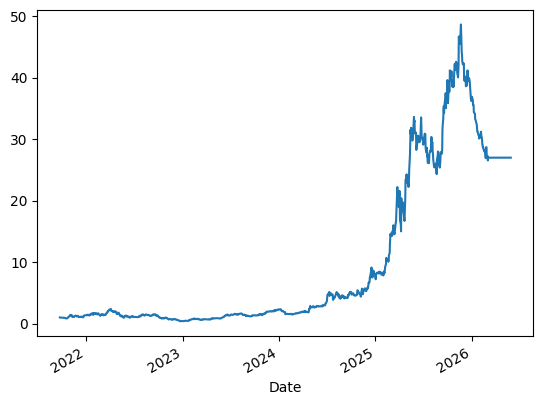

In [96]:
d = pd.read_parquet('tesla_xgb_sign_3_pnl.parquet')
np.exp(d["ret"].cumsum()).plot()

In [100]:
for f in Path(".").glob("*.parquet"):

    parts = f.stem.lower().split("_")

    if parts[-1] not in {"3", "5", "10", "30", "60"}:
        continue

    asset = parts[0]
    model_name = "_".join(parts[1:-1])
    h = int(parts[-1])

    if model_name not in {"logreg", "xgb_sign"}:
        continue

    preds = pd.read_parquet(f)

    start = 504 + 2 * em_map[f"target_{h}"]

    preds = preds.iloc[start:]

    if model_name == "logreg":
        pos = preds["Y_pred"]

    if model_name == "xgb_sign":
        pos = preds["Y_pred"].map({0: -1, 1: 0, 2: 1})

    close = dfs[asset]["Close"].squeeze()

    ret = pnl(
        pos=pos,
        close=close,
        h=h
    ).dropna()

    out = pd.DataFrame({
        "ret": ret,
        "pos": pos.reindex(ret.index).ffill()
    })

    out.index.name = "Date"

    out.to_parquet(
        f"{asset}_{model_name}_{h}_pnl.parquet"
    )

In [98]:
f = pd.read_parquet('tesla_xgb_sign_5.parquet')
f.head()

,Y_true,Y_pred
Date,,
2021-09-29,1,0
2021-09-30,2,0
2021-10-01,2,0
2021-10-04,2,0
2021-10-05,2,0


In [99]:
f = pd.read_parquet('tesla_ridge_5.parquet')
f.head()

,Y_true,Y_pred
Date,,
2021-09-29,0.001841,0.002845
2021-09-30,0.023110,0.000257
2021-10-01,0.013161,0.000251
2021-10-04,0.013232,0.010271
2021-10-05,0.031686,0.006713
